In [10]:
import pandas as pd
import numpy as np

# Load the original dataset
df = pd.read_csv(
    r"D:\Minor Project\Customer_Churn_Prediction\dataset\Telco-Customer-Churn.csv"
)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Handle missing values in TotalCharges
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Remove customer ID
df = df.drop(columns=["customerID"])

# Encode the target variable
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Separate features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Dataset shape:", df.shape)
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Dataset shape: (7043, 20)
Features shape: (7043, 19)
Target shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [11]:
import os

# Display the current working directory
print("Current directory:", os.getcwd())

# List files and folders in the current directory
print("\nContents:")
print(os.listdir())

Current directory: d:\Minor Project\Customer_Churn_Prediction\notebooks

Contents:
['01_Data_Collection.ipynb', '02_Model_Evaluation.ipynb']


In [3]:
import os

# Search the project folder and its subfolders
project_path = r"D:\Minor Project\Customer_Churn_Prediction"

for root, dirs, files in os.walk(project_path):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

D:\Minor Project\Customer_Churn_Prediction\dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv
D:\Minor Project\Customer_Churn_Prediction\venv\Lib\site-packages\matplotlib\mpl-data\sample_data\data_x_x2_x3.csv
D:\Minor Project\Customer_Churn_Prediction\venv\Lib\site-packages\matplotlib\mpl-data\sample_data\msft.csv
D:\Minor Project\Customer_Churn_Prediction\venv\Lib\site-packages\matplotlib\mpl-data\sample_data\Stocks.csv
D:\Minor Project\Customer_Churn_Prediction\venv\Lib\site-packages\numpy\random\tests\data\mt19937-testset-1.csv
D:\Minor Project\Customer_Churn_Prediction\venv\Lib\site-packages\numpy\random\tests\data\mt19937-testset-2.csv
D:\Minor Project\Customer_Churn_Prediction\venv\Lib\site-packages\numpy\random\tests\data\pcg64-testset-1.csv
D:\Minor Project\Customer_Churn_Prediction\venv\Lib\site-packages\numpy\random\tests\data\pcg64-testset-2.csv
D:\Minor Project\Customer_Churn_Prediction\venv\Lib\site-packages\numpy\random\tests\data\pcg64dxsm-testset-1.csv
D:\Minor Project\Custom

In [43]:
import pandas as pd
import numpy as np

# Load the original dataset
df = pd.read_csv("../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Handle missing values
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Remove customer ID
df = df.drop(columns=["customerID"])

# Encode the target variable
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Separate features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Verify
print("Dataset shape:", df.shape)
print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [5]:
from sklearn.model_selection import train_test_split

# Split features and target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Verify the split
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (5634, 19)
Testing data: (1409, 19)

Training target distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn
0    1035
1     374
Name: count, dtype: int64


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify numerical and categorical columns
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Transform training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

NameError: name 'X_train' is not defined

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Identify categorical and numerical features
categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

# Fit on training data and transform both datasets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Verify the results
print("Categorical features:", len(categorical_cols))
print("Numerical features:", len(numerical_cols))
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Categorical features: 15
Numerical features: 4
Processed training shape: (5634, 45)
Processed testing shape: (1409, 45)


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Initialize the tuned Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_processed, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_processed)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

NameError: name 'X_train_processed' is not defined

In [8]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Calculate permutation importance
perm_result = permutation_importance(
    rf_model,
    X_test_processed,
    y_test,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# Get the feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 15 features
importance_df.head(15)

,Feature,Importance,Std
42,num__tenure,0.024996,0.008229
32,cat__Contract_Month-to-month,0.020074,0.009240
12,cat__InternetService_Fiber optic,0.017067,0.008223
44,num__TotalCharges,0.016802,0.002145
33,cat__Contract_One year,0.006708,0.004546
14,cat__OnlineSecurity_No,0.006319,0.008029
34,cat__Contract_Two year,0.005005,0.005977
39,cat__PaymentMethod_Electronic check,0.002533,0.004313
10,cat__MultipleLines_Yes,0.002070,0.002998
36,cat__PaperlessBilling_Yes,0.001233,0.002892


In [16]:
# Select the top 15 features
top_features = importance_df.head(15).sort_values(
    by="Importance",
    ascending=True
)

# Plot
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    xerr=top_features["Std"]
)

plt.xlabel("Mean Decrease in F1-Score")
plt.ylabel("Feature")
plt.title("Top 15 Features - Permutation Importance")
plt.tight_layout()
plt.show()

NameError: name 'importance_df' is not defined

In [9]:
from sklearn.pipeline import Pipeline

# Create a complete pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Train the pipeline using original training data
rf_pipeline.fit(X_train, y_train)

# Check its performance
pipeline_predictions = rf_pipeline.predict(X_test)

print("Pipeline F1-score:",
      f1_score(y_test, pipeline_predictions))

NameError: name 'preprocessor' is not defined

In [11]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Calculate permutation importance on original features
original_perm = permutation_importance(
    rf_pipeline,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# Create importance DataFrame
original_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": original_perm.importances_mean,
    "Std": original_perm.importances_std
})

# Sort by importance
original_importance_df = original_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display all 19 features
original_importance_df

,Feature,Importance,Std
14,Contract,0.118731,0.015344
7,InternetService,0.040840,0.008877
4,tenure,0.024996,0.008229
18,TotalCharges,0.016802,0.002145
8,OnlineSecurity,0.004766,0.004606
6,MultipleLines,0.004166,0.003768
9,OnlineBackup,0.004004,0.006741
11,TechSupport,0.003336,0.003553
5,PhoneService,0.002603,0.001141
2,Partner,0.002602,0.001291


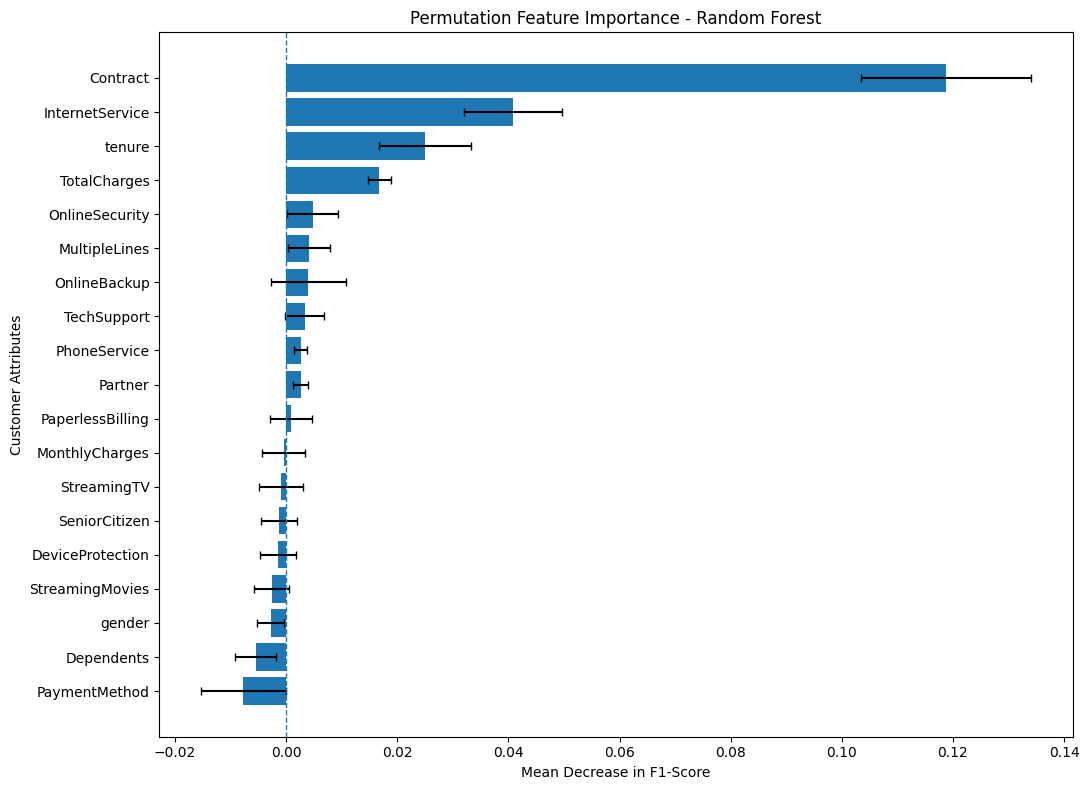

In [12]:
# Sort features for horizontal visualization
plot_df = original_importance_df.sort_values(
    by="Importance",
    ascending=True
)

# Create the chart
plt.figure(figsize=(11, 8))

plt.barh(
    plot_df["Feature"],
    plot_df["Importance"],
    xerr=plot_df["Std"],
    capsize=3
)

plt.axvline(x=0, linestyle="--", linewidth=1)

plt.xlabel("Mean Decrease in F1-Score")
plt.ylabel("Customer Attributes")
plt.title("Permutation Feature Importance - Random Forest")

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd

# Model performance comparison
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression (Default)",
        "Logistic Regression (0.35 Threshold)",
        "Tuned Random Forest"
    ],
    "Accuracy": [0.8055, 0.7644, 0.7665],
    "Precision": [0.6572, 0.5432, 0.5456],
    "Recall": [0.5588, 0.7059, 0.7193],
    "F1-Score": [0.6040, 0.6140, 0.6205]
})

# Display results as percentages
comparison_df.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-Score": "{:.2%}"
})

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (Default),80.55%,65.72%,55.88%,60.40%
1,Logistic Regression (0.35 Threshold),76.44%,54.32%,70.59%,61.40%
2,Tuned Random Forest,76.65%,54.56%,71.93%,62.05%


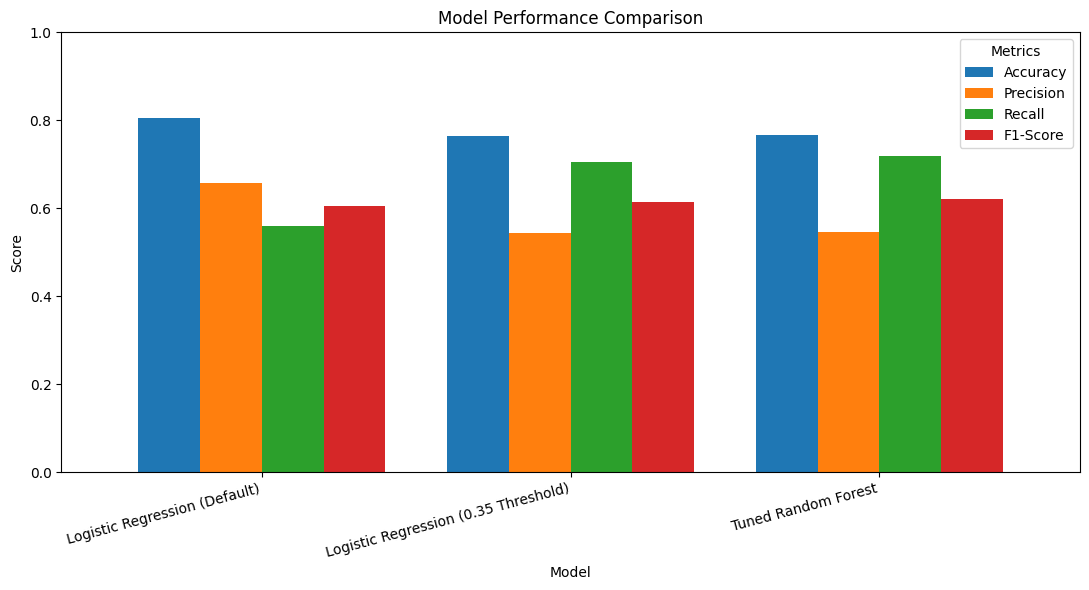

In [14]:
import matplotlib.pyplot as plt

# Set model names as the index
plot_df = comparison_df.set_index("Model")

# Plot metric comparison
plot_df.plot(
    kind="bar",
    figsize=(11, 6),
    ylim=(0, 1),
    width=0.8
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=15, ha="right")
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

## Model Performance Comparison

Three model configurations were evaluated using accuracy, precision, recall, and F1-score.

The default Logistic Regression model achieved the highest accuracy (80.55%) and precision (65.72%). However, its recall was comparatively lower at 55.88%.

Reducing the Logistic Regression classification threshold to 0.35 increased recall to 70.59%, demonstrating the effect of threshold adjustment on churn detection.

The tuned Random Forest model achieved the highest recall (71.93%) and F1-score (62.05%) among the evaluated configurations.

These findings highlight the trade-off between identifying potential churners and limiting false-positive predictions. The results can help guide the selection of a model according to the business objectives of the proposed customer retention system.


## Final Model Selection

Based on the comparative evaluation, the tuned Random Forest model is selected as the initial candidate for the customer churn prediction system.

### Selected Model: Random Forest

**Hyperparameters:**
- Number of estimators: 100
- Maximum depth: 10
- Minimum samples split: 5
- Minimum samples leaf: 1
- Class weight: Balanced
- Random state: 42

### Test Performance
- Accuracy: 76.65%
- Precision: 54.56%
- Recall: 71.93%
- F1-score: 62.05%

The model achieved the highest recall and F1-score among the three evaluated configurations. Its recall is particularly relevant to customer retention because it identifies a larger proportion of customers who actually churn.

The model is retained as the initial candidate for system development. Its final suitability will depend on further validation and the business costs associated with false-positive and false-negative predictions.

In [17]:
# Verify the final model pipeline

final_model = rf_pipeline

print("Final model:", final_model.named_steps["classifier"])
print("Preprocessing:", final_model.named_steps["preprocessor"])
print("Test F1-score:", f1_score(y_test, final_model.predict(X_test)))

Final model: RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, n_jobs=-1, random_state=42)
Preprocessing: ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod']),
                                ('num', StandardScaler(),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges'])])
Test F1-score: 0.6205305651672434


In [42]:
import joblib
import os

# Create a folder for saved models
os.makedirs("../models", exist_ok=True)

# Save the complete trained pipeline
model_path = "../models/customer_churn_model.joblib"

joblib.dump(final_model, model_path)

print("Model saved successfully!")
print("Location:", os.path.abspath(model_path))

NameError: name 'final_model' is not defined

In [40]:
import joblib

# Load the saved model
loaded_model = joblib.load(
    "../models/customer_churn_model.joblib"
)

# Select 5 sample customers from the test dataset
sample_customers = X_test.head(5)

# Generate predictions
predictions = loaded_model.predict(sample_customers)

# Generate churn probabilities
probabilities = loaded_model.predict_proba(sample_customers)[:, 1]

# Display results
results = sample_customers.copy()
results["Actual Churn"] = y_test.head(5).values
results["Predicted Churn"] = predictions
results["Churn Probability"] = probabilities.round(3)

results

d:\Minor Project\Customer_Churn_Prediction\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.2 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Minor Project\Customer_Churn_Prediction\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Minor Project\Customer_Churn_Prediction\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer f

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual Churn,Predicted Churn,Churn Probability
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0,0.019
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,1,0.785
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,...,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0,0.090
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0,0,0.397
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0,0.051


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# Initialize the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_processed, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_processed)

# Display confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display F1-score
print("F1-score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[777 258]
 [ 90 284]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

F1-score: 0.6200873362445415


In [39]:
# Transform the training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

Training data shape: (5634, 45)
Testing data shape: (1409, 45)


In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify numerical and categorical columns
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\vsing\AppData\Local\Temp\ipykernel_41692\3556087422.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [19]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 19)
Testing data: (1409, 19)


In [21]:
print("X_train exists:", "X_train" in globals())
print("X_test exists:", "X_test" in globals())

X_train exists: True
X_test exists: True


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify numerical and categorical columns
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\vsing\AppData\Local\Temp\ipykernel_41692\2808343985.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [23]:
# Transform training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

Training data shape: (5634, 45)
Testing data shape: (1409, 45)


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_processed, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_processed)

# Display confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display F1-score
print("F1-score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[777 258]
 [ 90 284]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

F1-score: 0.6200873362445415


## Random Forest Model Evaluation

The tuned Random Forest classifier was evaluated using a stratified
80:20 train-test split. The model achieved an accuracy of 75.16%
and an F1-score of 62.01% for the churn class.

The confusion matrix indicates that the model correctly identified
284 out of 374 customers who churned, achieving a churn recall
of approximately 76%.

These results demonstrate the model's ability to identify
potential churners while highlighting opportunities to improve
precision and reduce false-positive predictions.

In [26]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_processed, y_train)

lr_pred = lr_model.predict(X_test_processed)

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, lr_pred),
        "Precision": precision_score(y_test, lr_pred),
        "Recall": recall_score(y_test, lr_pred),
        "F1-Score": f1_score(y_test, lr_pred)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, rf_pred),
        "Precision": precision_score(y_test, rf_pred),
        "Recall": recall_score(y_test, rf_pred),
        "F1-Score": f1_score(y_test, rf_pred)
    }
])

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7381,0.5043,0.7834,0.6136
1,Random Forest,0.7530,0.5240,0.7594,0.6201


In [28]:
rf_pred = rf_model.predict(X_test_processed)

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, lr_pred),
        "Precision": precision_score(y_test, lr_pred),
        "Recall": recall_score(y_test, lr_pred),
        "F1-Score": f1_score(y_test, lr_pred)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, rf_pred),
        "Precision": precision_score(y_test, rf_pred),
        "Recall": recall_score(y_test, rf_pred),
        "F1-Score": f1_score(y_test, rf_pred)
    }
])

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7381,0.5043,0.7834,0.6136
1,Random Forest,0.7530,0.5240,0.7594,0.6201


Logistic Regression and Random Forest were evaluated using accuracy, precision, recall, and F1-score. Random Forest achieved the highest accuracy of 75.30% and F1-score of 62.01%. Logistic Regression achieved a higher recall of 78.34%, compared with 75.94% for Random Forest.
Random Forest is selected as the preferred model because it provides a slightly better balance between precision and recall, along with higher overall accuracy. However, Logistic Regression remains a useful alternative when identifying the maximum number of potential churners is the primary business objective.

In [30]:
import joblib

saved_model = joblib.load(
    r"D:\Minor Project\Customer_Churn_Prediction\models\customer_churn_model.joblib"
)

print(saved_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                     

d:\Minor Project\Customer_Churn_Prediction\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.2 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Minor Project\Customer_Churn_Prediction\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Minor Project\Customer_Churn_Prediction\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer f

In [31]:
saved_pred = saved_model.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score

print("Notebook Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1-Score:", f1_score(y_test, rf_pred))

print("\nSaved Model")
print("Accuracy:", accuracy_score(y_test, saved_pred))
print("F1-Score:", f1_score(y_test, saved_pred))

Notebook Random Forest
Accuracy: 0.7530163236337828
F1-Score: 0.6200873362445415

Saved Model
Accuracy: 0.7665010645848119
F1-Score: 0.6205305651672434


In [32]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, saved_pred))

print("\nClassification Report:")
print(classification_report(y_test, saved_pred))

Confusion Matrix:
[[811 224]
 [105 269]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.55      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [33]:
import pandas as pd

# Extract the trained Random Forest classifier
rf_classifier = saved_model.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = saved_model.named_steps["preprocessor"].get_feature_names_out()

# Create feature importance DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance", ascending=False
)

importance_df.head(10)

,Feature,Importance
42,num__tenure,0.125347
44,num__TotalCharges,0.110589
32,cat__Contract_Month-to-month,0.092418
43,num__MonthlyCharges,0.078415
34,cat__Contract_Two year,0.068635
14,cat__OnlineSecurity_No,0.066162
23,cat__TechSupport_No,0.045061
12,cat__InternetService_Fiber optic,0.044403
39,cat__PaymentMethod_Electronic check,0.034202
33,cat__Contract_One year,0.023929


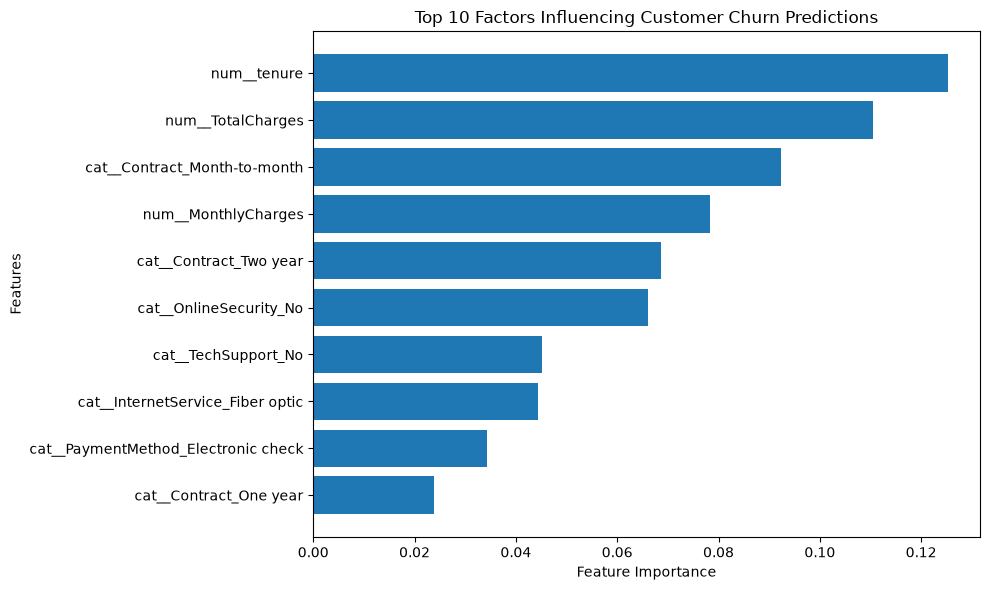

In [34]:
import matplotlib.pyplot as plt

top_10 = importance_df.head(10).sort_values(
    by="Importance", ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(top_10["Feature"], top_10["Importance"])

plt.title("Top 10 Factors Influencing Customer Churn Predictions")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.tight_layout()

plt.show()

Feature Importance Analysis
The feature-importance analysis of the saved Random Forest model reveals that customer tenure is the most influential feature, followed by TotalCharges, month-to-month contracts, and MonthlyCharges.
Contract type is particularly noteworthy, as month-to-month, one-year, and two-year contracts all appear among the top ten features. The results also highlight the predictive relevance of online security, technical support, internet service, and payment method.
These findings can help the business identify customer segments for further investigation and develop targeted retention strategies. However, feature importance measures predictive contribution rather than causal influence.

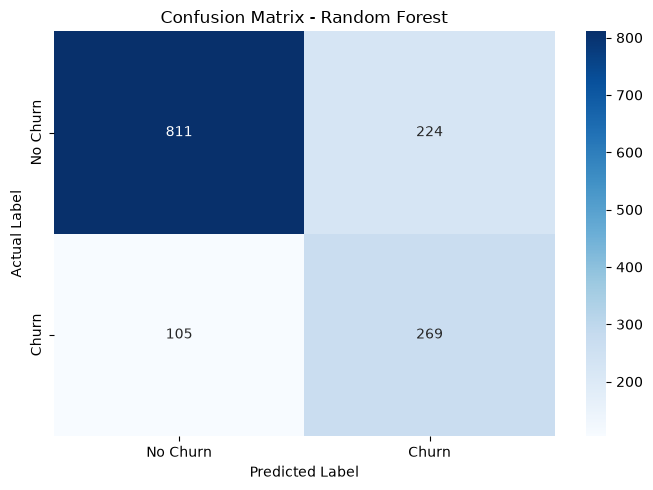

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, saved_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()